# SAMOO on the Fonseca-Fleming problem via the `pestpp-api` and its GPR library

This notebook runs surrogate-assisted multi-objective optimization (SAMOO) on the Fonseca-Fleming test problem, with two decision variables and two objectives. Everything runs from one Python process through the `pestpp-api` C API: the real-model runs, the surrogate-model runs and the optimizer steps. The surrogate is the Gaussian process regression (GPR) library in `pestpp-api` (`pestpp.gp_local_predict`, a local approximate GP).

SAMOO alternates between an expensive "real" model and a cheap GP trained on the real evaluations made so far:

1. Latin hypercube sample of the initial training set.
2. **Outer iteration**: evaluate the points on the real model.
3. Pareto dominance evaluation of every real evaluation so far (the outer repository).
4. (Re)train the GP on every real evaluation so far.
5. **Inner iterations**: run MOU against the GP, with probabilistic Pareto dominance
   (`mou_env_selector(NSGA_PPD)`), so the GP's predictive standard deviation affects which points survive.
6. **Resample**: choose infill points from the inner run's fronts. They are evaluated on the real model as the next outer iteration (back to step 2).

How the steps map onto the API:

| Step | This notebook |
|---|---|
| model and control files | `build_pst()` writes two workdirs: the outer (real model) and the inner template (GP) |
| outer iterations (steps 2-3) | one long-lived outer `Mou` session. Each round is one generation whose candidates are replaced by the infill points through `par_view()` |
| outer repository (step 3) | the outer session's own archive (`outer.archive_dv()`/`archive_obs()`), which covers every round |
| (re)train (step 4) | every real evaluation so far, written to `gp_training.npz` for the surrogate runs to read |
| inner iterations (step 5) | a fresh inner `Mou` session per round, started from `inner_start()` through mou's dv and obs restart files, with `pestpp.gp_local_predict` in `surrogate_forward_run.py` |
| resample (step 6) | `resample()`, which reads the inner run's `fon.pareto.summary.csv` |


## Setup

In [1]:
import os
import shutil
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Patch
from matplotlib.lines import Line2D
import pyemu
from scipy.stats import qmc

REPO_ROOT = os.path.dirname(os.getcwd())  # this notebook lives in <repo>/examples
sys.path.insert(0, os.path.join(REPO_ROOT, "python"))
from pestpp import Mou, gp_local_predict, find_library

print("pestpp-api library:", find_library())

# --- the problem: Fonseca-Fleming, x1, x2 in [-4, 4], minimize both objectives ---
DV_NAMES = ["x1", "x2"]
BOUNDS = {name: (-4.0, 4.0) for name in DV_NAMES}
OBJ_NAMES = ["obj1", "obj2"]
SD_NAMES = [name + "_sd" for name in OBJ_NAMES]    # the <objective>_sd names NSGA_PPD looks for

# --- SAMOO settings ---
MAX_INFILL = 30         # infill points per outer round
OUTER_POP = MAX_INFILL  # the outer candidate buffer must match the infill count exactly
N_OUTER = 5             # outer rounds after outer 0
N_INNER = 20            # inner generations per round
INNER_POP = 30          # inner PSO swarm size
INNER_ARCHIVE = 30      # inner archive (repository) size
PPD_BETA = 0.5          # mou_ppd_beta
LAGP_START, LAGP_END = 6, 20   # local GP design size: grown from 6 to 20 points per prediction

N_WORKER_OUTER = 8
N_WORKER_INNER = 8

ROOT = "fonseca_samoo"
OUTER_DIR = os.path.join(ROOT, "outer")
INNER_TEMPLATE = os.path.join(ROOT, "inner_template")   # copied once per round, never run in
INNER_ROUNDS = os.path.join(ROOT, "inner_rounds")       # round_01/, round_02/, ...
MOO_DIR = os.path.join(ROOT, "moo_only")                 # comparison run without a surrogate
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)
os.makedirs(ROOT)

pestpp-api library: /Users/rqmacasieb/Documents/Github/pestpp/bin/pestpp-api.dylib


## The test problem and its reference Pareto front

```
minimize   f1(x) = 1 - exp(-sum_{i=1..n} (x_i - 1/sqrt(n))^2)
minimize   f2(x) = 1 - exp(-sum_{i=1..n} (x_i + 1/sqrt(n))^2)
with       n = 2,  x1, x2 in [-4, 4]
```

The Pareto set is the segment `x1 = x2 = t`, `t` in `[-1/sqrt(n), 1/sqrt(n)]`, and the front is a single connected, concave curve from `(0, 1 - exp(-4))` to `(1 - exp(-4), 0)`. It is saved to `fonseca_samoo/fonseca_reference_front.csv`.

In [ ]:
def fonseca(X):
    X = np.atleast_2d(X)
    c = 1.0 / np.sqrt(X.shape[1])
    f1 = 1.0 - np.exp(-np.sum((X - c) ** 2, axis=1))
    f2 = 1.0 - np.exp(-np.sum((X + c) ** 2, axis=1))
    return np.column_stack([f1, f2])

t = np.linspace(-1.0 / np.sqrt(len(DV_NAMES)), 1.0 / np.sqrt(len(DV_NAMES)), 2001)
X_true = np.column_stack([t] * len(DV_NAMES))
true_front = pd.DataFrame(np.column_stack([X_true, fonseca(X_true)]), columns=DV_NAMES + OBJ_NAMES)
true_front.to_csv(os.path.join(ROOT, "fonseca_reference_front.csv"), index=False)
TRUE_F = true_front[OBJ_NAMES].values
print("reference front: {0} points on x1 = x2 in [{1:.4f}, {2:.4f}]".format(
    len(true_front), t[0], t[-1]))

reference front: 2001 points on x1 = x2 in [-0.7071, 0.7071]


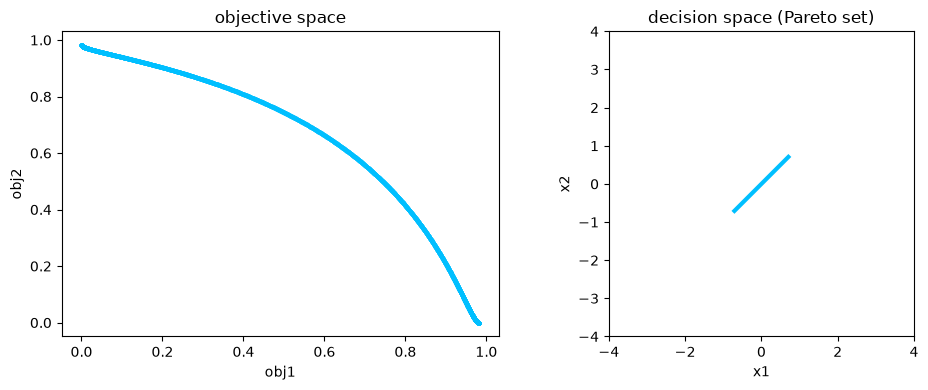

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_front["obj1"], true_front["obj2"], s=4, c="deepskyblue")
axes[0].set_xlabel("obj1"), axes[0].set_ylabel("obj2"), axes[0].set_title("objective space")
axes[1].plot(true_front["x1"], true_front["x2"], c="deepskyblue", lw=3)
axes[1].set_xlim(*BOUNDS["x1"]), axes[1].set_ylim(*BOUNDS["x2"]), axes[1].set_aspect("equal")
axes[1].set_xlabel("x1"), axes[1].set_ylabel("x2"), axes[1].set_title("decision space (Pareto set)")
plt.tight_layout()
plt.show()

## Model files and control files

Both sessions use the same template (`dv.dat.tpl`) and instruction file (`output.dat.ins`), so their parameter and observation names match. Each writes `obj1`, `obj2`, `obj1_sd` and `obj2_sd`. The real model writes zero for the standard deviations. The two sessions run different forward scripts:

- `real_forward_run.py`: the Fonseca-Fleming function.
- `surrogate_forward_run.py`: predicts both objectives with `pestpp_lib.gp_local_predict(...)`,
  a local approximate GP (ALC design grown from `LAGP_START` to `LAGP_END` points,
  squared-exponential kernel, lengthscale estimated per prediction point). It imports `pestpp_lib`
  directly rather than the `pestpp` package, which avoids importing `pyemu` in every candidate
  subprocess.

Both scripts read the decision variables by name from `dv.dat`, so they don't depend on how many
there are. The inner control file adds the PPD options: `mou_env_selector(NSGA_PPD)`,
`mou_ppd_beta(PPD_BETA)`, `mou_population_size(INNER_POP)` and
`mou_max_archive_size(INNER_ARCHIVE)`. Both control files use `mou_generator(pso)` with
`mou_pso_alpha(2)`.

In [4]:
REAL_FORWARD_RUN = """import numpy as np

vals = dict(line.split()[:2] for line in open("dv.dat") if line.strip())
x = np.array([float(vals[name]) for name in DV_NAMES])
c = 1.0 / np.sqrt(len(x))
obj1 = 1.0 - np.exp(-np.sum((x - c) ** 2))
obj2 = 1.0 - np.exp(-np.sum((x + c) ** 2))
with open("output.dat", "w") as f:
    f.write("obj1 {0!r}\\n".format(float(obj1)))
    f.write("obj2 {0!r}\\n".format(float(obj2)))
    f.write("obj1_sd 0.0\\n")
    f.write("obj2_sd 0.0\\n")
""".replace("DV_NAMES", repr(DV_NAMES))

SURROGATE_FORWARD_RUN = """import sys
import numpy as np
sys.path.insert(0, PESTPP_PKG_DIR)
from pestpp_lib import gp_local_predict

vals = dict(line.split()[:2] for line in open("dv.dat") if line.strip())
x = np.array([[float(vals[name]) for name in DV_NAMES]])

train = np.load("gp_training.npz")
mean, sd = {}, {}
for k, name in enumerate(["obj1", "obj2"]):
    pred = gp_local_predict(train["X"], train["Z"][:, k], x, start=LAGP_START, end=LAGP_END,
                            method="alc")
    mean[name] = float(pred["mean"][0])
    sd[name] = float(np.sqrt(max(pred["s2"][0], 0.0)))

# same line order as output.dat.ins: the objectives, then their sd
with open("output.dat", "w") as f:
    for name in ["obj1", "obj2"]:
        f.write("{0} {1!r}\\n".format(name, mean[name]))
    for name in ["obj1", "obj2"]:
        f.write("{0}_sd {1!r}\\n".format(name, sd[name]))
"""
SURROGATE_FORWARD_RUN = (SURROGATE_FORWARD_RUN
                         .replace("PESTPP_PKG_DIR", repr(os.path.join(REPO_ROOT, "python", "pestpp")))
                         .replace("DV_NAMES", repr(DV_NAMES))
                         .replace("LAGP_START", str(LAGP_START))
                         .replace("LAGP_END", str(LAGP_END)))


def build_pst(workdir, forward_run_text, forward_run_name, population_size, noptmax,
              extra_options=None):
    os.makedirs(workdir)
    with open(os.path.join(workdir, forward_run_name), "w") as f:
        f.write(forward_run_text)
    with open(os.path.join(workdir, "dv.dat.tpl"), "w") as f:
        f.write("ptf ~\n" + "".join("{0} ~   {0}   ~\n".format(n) for n in DV_NAMES))
    with open(os.path.join(workdir, "dv.dat"), "w") as f:
        f.write("".join("{0} 1.0\n".format(n) for n in DV_NAMES))
    names = OBJ_NAMES + SD_NAMES
    with open(os.path.join(workdir, "output.dat.ins"), "w") as f:
        f.write("pif ~\n" + "".join("l1 w !{0}!\n".format(n) for n in names))
    with open(os.path.join(workdir, "output.dat"), "w") as f:
        f.write("".join("{0} 0.0\n".format(n) for n in names))

    here = os.getcwd()
    os.chdir(workdir)
    try:
        pst = pyemu.Pst.from_io_files("dv.dat.tpl", "dv.dat", "output.dat.ins", "output.dat")
    finally:
        os.chdir(here)

    par = pst.parameter_data
    par.loc[:, ["partrans", "pargp", "parchglim"]] = ["none", "decvar", "relative"]
    for name, (lb, ub) in BOUNDS.items():
        par.loc[name, ["parlbnd", "parval1", "parubnd"]] = [lb, 1.0, ub]

    obs = pst.observation_data
    obs.loc[OBJ_NAMES, ["weight", "obgnme"]] = [1.0, "l_obj"]
    # nonzero weight: NSGA_PPD only looks for <objective>_sd among nonzero-weighted observations.
    # group "obs" has no l_/g_ prefix, so it is neither an objective nor a constraint
    obs.loc[SD_NAMES, ["weight", "obgnme"]] = [1.0, "obs"]

    pst.model_command = "python {0}".format(forward_run_name)
    pst.pestpp_options["opt_dec_var_groups"] = "decvar"
    pst.pestpp_options["mou_objectives"] = ",".join(OBJ_NAMES)
    pst.pestpp_options["mou_population_size"] = population_size
    pst.pestpp_options["mou_generator"] = "pso"
    pst.pestpp_options["mou_pso_alpha"] = 2
    pst.pestpp_options["panther_agent_freeze_on_fail"] = True
    pst.pestpp_options["mou_save_population_every"] = 1
    pst.pestpp_options.update(extra_options or {})
    pst.control_data.noptmax = noptmax

    pst_name = "fon.pst"
    pst.write(os.path.join(workdir, pst_name))
    return pst_name


outer_pst = build_pst(OUTER_DIR, REAL_FORWARD_RUN, "real_forward_run.py",
                      population_size=OUTER_POP, noptmax=N_OUTER)
inner_pst = build_pst(INNER_TEMPLATE, SURROGATE_FORWARD_RUN, "surrogate_forward_run.py",
                      population_size=INNER_POP, noptmax=N_INNER,
                      extra_options={"mou_env_selector": "NSGA_PPD",
                                     "mou_ppd_beta": PPD_BETA,
                                     "mou_max_archive_size": INNER_ARCHIVE})
for d in (OUTER_DIR, INNER_TEMPLATE):
    print(d, sorted(os.listdir(d)))

noptmax:5, npar_adj:2, nnz_obs:4
noptmax:20, npar_adj:2, nnz_obs:4
fonseca_samoo/outer ['dv.dat', 'dv.dat.tpl', 'fon.pst', 'output.dat', 'output.dat.ins', 'real_forward_run.py']
fonseca_samoo/inner_template ['dv.dat', 'dv.dat.tpl', 'fon.pst', 'output.dat', 'output.dat.ins', 'surrogate_forward_run.py']


## Helpers: LHS, inner starting population, resampling, IGD

- `lhs_sample()`: a Latin hypercube over the bounds. `set_par_df()` matches rows by name
  against the live population, so the sample reuses the names the session already drew.
- `inner_start()`: the inner run's starting population, decision variables and objectives
  together, on the same member names. Take the outer repository (the outer session's archive).  If it has fewer points than the inner swarm, add a random sample of the latest outer round's evaluations that aren't in it, then of the rest of the history. If it has more, sample the swarm size from it. Every member is a real evaluation, so the objectives are the real ones and their sd are 0.0. The inner session loads them through `mou_dv_population_file` and `mou_obs_population_restart_file`, so generation 0 needs no GP runs.
- `resample()`: read the inner run's `fon.pareto.summary.csv`, drop members whose decision variables are already in the training set, then take points newest generation first, front by front. When a front is bigger than the space left, keep the largest crowding distances. The fronts are the ones pestpp-mou ranked under PPD. The API doesn't expose per-generation front ranks, so this is the one file the notebook reads back.
- `pad_to()`: top up the infill with LHS points if the inner run offers too few new ones, because the outer candidate buffer has a fixed row count.
- `igd()`: inverted generational distance from the reference front to a set of points: the mean distance from each reference point to its nearest point in the set, in objectives scaled to the reference front's range. Lower is better. It penalizes both points away from the front and parts of the front with no points near them.

In [5]:
def lhs_sample(index, seed):
    sampler = qmc.LatinHypercube(d=len(DV_NAMES), seed=seed)
    lb = np.array([BOUNDS[n][0] for n in DV_NAMES])
    ub = np.array([BOUNDS[n][1] for n in DV_NAMES])
    x = qmc.scale(sampler.random(len(index)), lb, ub)
    return pd.DataFrame(x, columns=DV_NAMES, index=index)


def inner_start(n, repo_dv, repo_obs, hist_dv, hist_obs, latest, seed):
    """the inner run's starting population, as matching (dv, obs) frames on the same member
    names. Every member is a real evaluation, so its obs are the real objectives and its sd are
    0 (what the real model reports). Take the outer repository; if it has more than n points,
    sample n from it. If fewer, fill from the latest outer round's evaluations, then from the
    rest of the history"""
    rng = np.random.default_rng(seed)
    hist_dv = hist_dv.loc[~hist_dv.index.duplicated(keep="last")]
    hist_obs = hist_obs.loc[~hist_obs.index.duplicated(keep="last")]
    if len(repo_dv) >= n:
        names = list(repo_dv.index[rng.choice(len(repo_dv), n, replace=False)])
    else:
        names = list(repo_dv.index)
        for pool in (latest, hist_dv.index):
            pool = [m for m in pool if m not in set(names)]
            take = min(n - len(names), len(pool))
            names += [pool[i] for i in rng.choice(len(pool), take, replace=False)]
    if len(names) < n:
        raise ValueError("only {0} real evaluations for an inner population of {1}".format(
            len(names), n))
    dv = pd.concat([repo_dv, hist_dv]).loc[lambda d: ~d.index.duplicated()].loc[names, DV_NAMES]
    obs = pd.concat([repo_obs, hist_obs]).loc[lambda d: ~d.index.duplicated()].loc[names, OBJ_NAMES]
    obs = obs.assign(**{sd: 0.0 for sd in SD_NAMES})
    return dv, obs


def resample(summary, inner_dv, train_dv, n_infill):
    """newest generation first, then front by front, crowding
    distance within a front that does not fit. summary is the inner run's pareto summary,
    inner_dv maps every member the inner run evaluated to its decision variables."""
    summary = summary.copy()
    summary["member"] = summary["member"].str.lower()
    known = set(map(tuple, np.round(train_dv[DV_NAMES].values, 12)))
    dup = [tuple(r) in known for r in np.round(inner_dv[DV_NAMES].values, 12)]
    summary = summary.loc[~summary["member"].isin(inner_dv.index[dup])]

    chosen = []
    for gen in sorted(summary["generation"].unique(), reverse=True):
        at_gen = summary.loc[summary["generation"] == gen].drop_duplicates("member")
        at_gen = at_gen.loc[~at_gen["member"].isin(chosen)]
        for front in sorted(at_gen["nsga2_front"].unique()):
            room = n_infill - len(chosen)
            if room <= 0:
                break
            members = at_gen.loc[at_gen["nsga2_front"] == front]
            if len(members) > room:
                members = members.sort_values("nsga2_crowding_distance", ascending=False)
            chosen.extend(members["member"].iloc[:room].tolist())
        if len(chosen) >= n_infill:
            break
    return inner_dv.loc[chosen, DV_NAMES]


def pad_to(df, n, seed):
    """top up with LHS points when the inner run offered fewer than n new points: the outer
    candidate buffer that par_view() writes into has a fixed row count"""
    if len(df) >= n:
        return df.iloc[:n]
    print("    only {0} infill points available, padding with {1} LHS points".format(
        len(df), n - len(df)))
    extra = lhs_sample(["pad_{0}_{1}".format(seed, i) for i in range(n - len(df))], seed=seed)
    return pd.concat([df, extra])


F_LO, F_HI = TRUE_F.min(axis=0), TRUE_F.max(axis=0)


def igd(F):
    """mean distance from each reference-front point to the nearest point of F, in objectives
    scaled to the reference front's range"""
    A = (TRUE_F - F_LO) / (F_HI - F_LO)
    B = (np.asarray(F, dtype=float) - F_LO) / (F_HI - F_LO)
    return float(np.mean(np.min(np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2), axis=1)))

## Outer 0: the initial training set on the real model

`initialize(defer_runs=True)` draws the population the control file asks for and stops before
running it. The LHS sample replaces it through `set_par_df()`, then the runs are queued, run and
processed.

After this cell, `outer.archive_dv()`/`archive_obs()` hold the outer repository.
`history_dv`/`history_obs` keep every real evaluation for training the GP, including points that
are later dropped from the population and archive. `repo_history` keeps the outer repository after
each round.

processing control file fon.pst
Note: 3 unused lines in pest control file, see rec file...


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....:::::::::____  ... :
   :... `:~    ^~-:::::..  .........:::::-~^    ~::.::::
   `.::. `\   (8)  \b:::..::.:.:::::::d/  (8)   /'.::::'
    ::::.  ~-._v    |b.::::::::::::::d|    v_.-~..:::::
    `.:::::... ~~^?888b..:::::::::::d888P^~...::::::::'
     `.::::::::::....~~~ .:::::::::~~~:::::::::::::::'
      `..:::::::::::   .   ....::::    ::::::::::::,'
        `. .:::::::    .      .::::.    ::::::::'.'
          `._ .:::    .        :::::.    :::::_.'
    

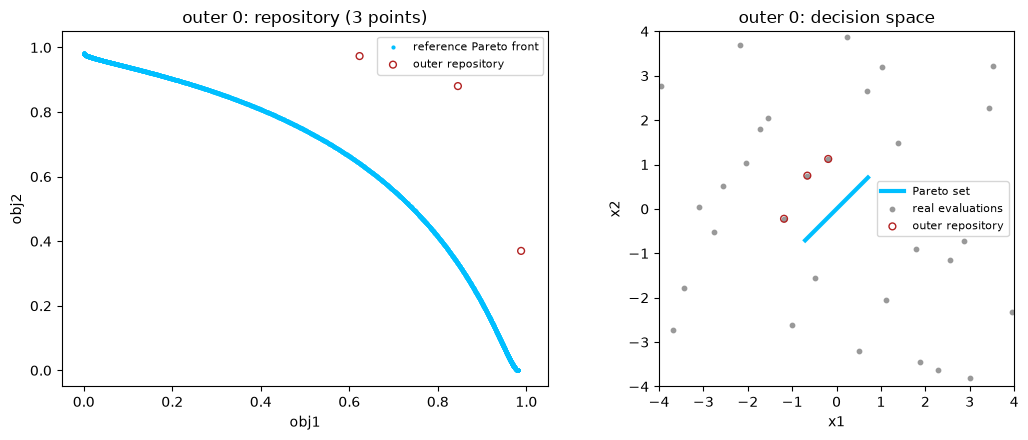

In [6]:
t0 = time.time()
outer = Mou.from_pst(outer_pst, workdir=OUTER_DIR, workers=N_WORKER_OUTER, port=4041)
outer.set_option("random_seed", 42)

outer.initialize(defer_runs=True)
initial_dv = lhs_sample(outer.dv_pop().index, seed=42)
outer.set_par_df(initial_dv)
outer.queue_runs()
outer.run()
outer.process_runs()
# read before finish_initialize(): it drops members that duplicate another in objective space,
# which happens here because Fonseca-Fleming is flat at (1, 1) far from the Pareto set
history_dv = [outer.dv_pop(lower=True)[DV_NAMES]]
history_obs = [outer.obs_pop(lower=True)[OBJ_NAMES]]
outer.finish_initialize()

repo_history = [(outer.archive_dv(lower=True)[DV_NAMES], outer.archive_obs(lower=True)[OBJ_NAMES])]

print("outer 0: {0} real evaluations, {1} in the outer repository, IGD = {2:.4f}, {3:.1f}s".format(
    len(history_obs[0]), len(repo_history[0][1]), igd(repo_history[0][1].values), time.time() - t0))

F_XLIM = (-0.05, 1.05)   # fixed axes around the objectives' range, so the rounds can be compared
F_YLIM = (-0.05, 1.05)


def plot_outer(k, ax):
    repo_obs = repo_history[k][1]
    ax.scatter(TRUE_F[:, 0], TRUE_F[:, 1], s=4, c="deepskyblue", label="reference Pareto front")
    ax.scatter(repo_obs["obj1"], repo_obs["obj2"], s=24, facecolors="none",
               edgecolors="firebrick", zorder=10, label="outer repository")
    ax.set_xlim(*F_XLIM), ax.set_ylim(*F_YLIM)
    ax.set_xlabel("obj1"), ax.set_ylabel("obj2")
    ax.set_title("outer {0}: repository ({1} points)".format(k, len(repo_obs)))
    ax.legend(fontsize=8)


def plot_dv(k, ax):
    """decision space: every real evaluation up to round k, and the repository after it"""
    seen = pd.concat(history_dv[:k + 1])
    repo_dv = repo_history[k][0]
    ax.plot(true_front["x1"], true_front["x2"], c="deepskyblue", lw=3, label="Pareto set")
    ax.scatter(seen["x1"], seen["x2"], s=10, c="0.6", label="real evaluations")
    ax.scatter(repo_dv["x1"], repo_dv["x2"], s=24, facecolors="none", edgecolors="firebrick",
               zorder=10, label="outer repository")
    ax.set_xlim(*BOUNDS["x1"]), ax.set_ylim(*BOUNDS["x2"]), ax.set_aspect("equal")
    ax.set_xlabel("x1"), ax.set_ylabel("x2")
    ax.set_title("outer {0}: decision space".format(k))
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_outer(0, axes[0])
plot_dv(0, axes[1])
plt.tight_layout()
plt.show()

## The outer/inner loop

Each round:

1. **Train (step 4).** Write every real evaluation so far to `gp_training.npz` in a fresh copy of
   the inner template (`inner_rounds/round_NN/`). The workers copy the workdir when they start,
   so this happens before the inner session is created. Each round gets its own directory, so its
   per-generation output isn't overwritten by the next round.
2. **Inner iterations (step 5).** A fresh inner `Mou` session, with its own `noptmax=N_INNER`,
   starts from `inner_start()` and runs `N_INNER` generations against the GP under `NSGA_PPD`.
   Each generation is a deferred `solve()`, so the loop can read every candidate's decision
   variables and GP predictions (`cand.par_df()`/`obs_df()`). The pareto summary ranks parents and
   candidates together, so `resample()` needs all of them, not only the survivors.
3. **Resample (step 6).** `resample()` picks `MAX_INFILL` points not already in the training set.
4. **Outer iteration (steps 2-3).** `outer.solve(defer_runs=True)` makes the next generation's
   candidates. Their decision variables are overwritten with the infill points through
   `par_view()`, and the batch is run on the real model. `cand.par_df()`/`cand.obs_df()` are read
   after `process_runs()` and before `finish_solve()`, the only point where every real evaluation
   is visible before environmental selection drops some. `finish_solve()` then updates the outer
   archive.

In [7]:
rounds = []
for round_ in range(1, N_OUTER + 1):
    t_round = time.time()
    train_dv = pd.concat(history_dv)
    train_obs = pd.concat(history_obs)

    # --- step 4: (re)train - write the training set where the surrogate runs will read it ---
    round_dir = os.path.join(INNER_ROUNDS, "round_{0:02d}".format(round_))
    shutil.copytree(INNER_TEMPLATE, round_dir)
    np.savez(os.path.join(round_dir, "gp_training.npz"), X=train_dv[DV_NAMES].values,
             Z=train_obs[OBJ_NAMES].values)

    # --- step 5: inner iterations against the GP ---
    inner = Mou.from_pst(inner_pst, workdir=round_dir, workers=N_WORKER_INNER, port=4042,
                         worker_root=os.path.join(ROOT, "inner_workers"))
    inner.set_option("random_seed", 1000 + round_)
    # restart from real evaluations: dv AND obs, so generation 0 is not re-run on the GP.
    # mou's own restart files, because obs can only be set this way - a deferred initialize
    # would run the population and overwrite them
    start_dv, start_obs = inner_start(INNER_POP, *repo_history[-1], train_dv, train_obs,
                                      latest=history_dv[-1].index, seed=100 + round_)
    start_dv.to_csv(os.path.join(round_dir, "start.dv_pop.csv"))
    start_obs.to_csv(os.path.join(round_dir, "start.obs_pop.csv"))
    inner.set_option("mou_dv_population_file", "start.dv_pop.csv")
    inner.set_option("mou_obs_population_restart_file", "start.obs_pop.csv")
    n_init = inner.initialize(defer_runs=True)
    assert n_init == 0, "restart should need no runs, got {0}".format(n_init)
    inner.finish_initialize()

    # every member the inner run evaluates: generation 0, then each generation's candidates,
    # read in the deferred-solve window. The pareto summary ranks parents AND candidates, so
    # the surviving population alone would miss members that resample() can pick
    inner_dvs = [inner.dv_pop(lower=True)[DV_NAMES]]
    inner_obss = [inner.obs_pop(lower=True)[OBJ_NAMES + SD_NAMES]]
    for gen in range(N_INNER):
        inner.solve(defer_runs=True)
        inner.queue_runs()
        inner.run()
        inner.process_runs()
        c = inner.candidates()[0]
        inner_dvs.append(c.par_df(lower=True)[DV_NAMES])
        inner_obss.append(c.obs_df(lower=True)[OBJ_NAMES + SD_NAMES])
        inner.finish_solve(defer_runs=True)
    inner.finalize()
    inner.close()

    inner_dv = pd.concat(inner_dvs)
    inner_obs = pd.concat(inner_obss)
    inner_dv = inner_dv.loc[~inner_dv.index.duplicated()]
    inner_obs = inner_obs.loc[~inner_obs.index.duplicated()]

    # --- step 6: resample infill points from the inner run's PPD fronts ---
    summary = pd.read_csv(os.path.join(round_dir, "fon.pareto.summary.csv"))
    infill_dv = pad_to(resample(summary, inner_dv, train_dv, MAX_INFILL), OUTER_POP,
                       seed=900 + round_)

    # --- steps 2-3: evaluate the infill points on the real model ---
    outer.solve(defer_runs=True)
    cand = outer.candidates()[0]
    cols = list(cand.par_df(lower=True).columns)
    with cand.par_view() as view:
        np.asarray(view)[:, :] = infill_dv[cols].values
    outer.queue_runs()
    outer.run()
    outer.process_runs()
    real_dv = cand.par_df(lower=True)[DV_NAMES]
    real_obs = cand.obs_df(lower=True)[OBJ_NAMES]
    history_dv.append(real_dv)
    history_obs.append(real_obs)
    step = outer.finish_solve(defer_runs=True)

    repo_dv = outer.archive_dv(lower=True)[DV_NAMES]
    repo_obs = outer.archive_obs(lower=True)[OBJ_NAMES]
    repo_history.append((repo_dv, repo_obs))

    # the last inner generation's first PPD front (the "Pareto cloud"), with the
    # GP predictions and sd that NSGA_PPD sorted on
    last = summary.loc[summary["generation"] == summary["generation"].max()].copy()
    last["member"] = last["member"].str.lower()
    cloud = inner_obs.loc[last.loc[last["nsga2_front"] == 1, "member"].unique()]
    # infill points whose real evaluation made it into the outer repository
    infill_pred = inner_obs.reindex(infill_dv.index)
    success = np.isin(real_dv.index, repo_dv.index)

    rounds.append(dict(train_dv=train_dv, cloud=cloud, infill_dv=infill_dv,
                       infill_pred=infill_pred, real_obs=real_obs, success=success))
    print("outer {0}: {1} real evals so far, repository {2} points ({3} new from this round), "
          "IGD = {4:.4f}, {5:.1f}s".format(
              round_, len(pd.concat(history_obs)), len(repo_obs), int(success.sum()),
              igd(repo_obs.values), time.time() - t_round))

print("SAMOO total: {0} real evaluations, {1:.1f}s".format(len(pd.concat(history_obs)),
                                                            time.time() - t0))

processing control file fon.pst
Note: 3 unused lines in pest control file, see rec file...


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....:::::::::____  ... :
   :... `:~    ^~-:::::..  .........:::::-~^    ~::.::::
   `.::. `\   (8)  \b:::..::.:.:::::::d/  (8)   /'.::::'
    ::::.  ~-._v    |b.::::::::::::::d|    v_.-~..:::::
    `.:::::... ~~^?888b..:::::::::::d888P^~...::::::::'
     `.::::::::::....~~~ .:::::::::~~~:::::::::::::::'
      `..:::::::::::   .   ....::::    ::::::::::::,'
        `. .:::::::    .      .::::.    ::::::::'.'
          `._ .:::    .        :::::.    :::::_.'
    

## Round by round: inner Pareto cloud and outer repository

- **Left, inner:** the first PPD front of the last inner generation (the "Pareto cloud"), at the
  GP-predicted positions, with a +/-1.5 sd ellipse for each point. Red crosses are the infill points at their predicted positions. Filled red markers are the infill points whose real evaluation entered the outer repository ("successful infill").
- **Middle, outer:** the outer repository after the round, against the reference front.
- **Right, decision space:** every real evaluation so far and the outer repository, against the Pareto set (the `x1 = x2` segment).

Near the parts of the front the repository already covers, the ellipses shrink as the training set grows. Far from the training data they stay large, and those are the
points PPD can still keep even when the GP mean puts them behind the front.

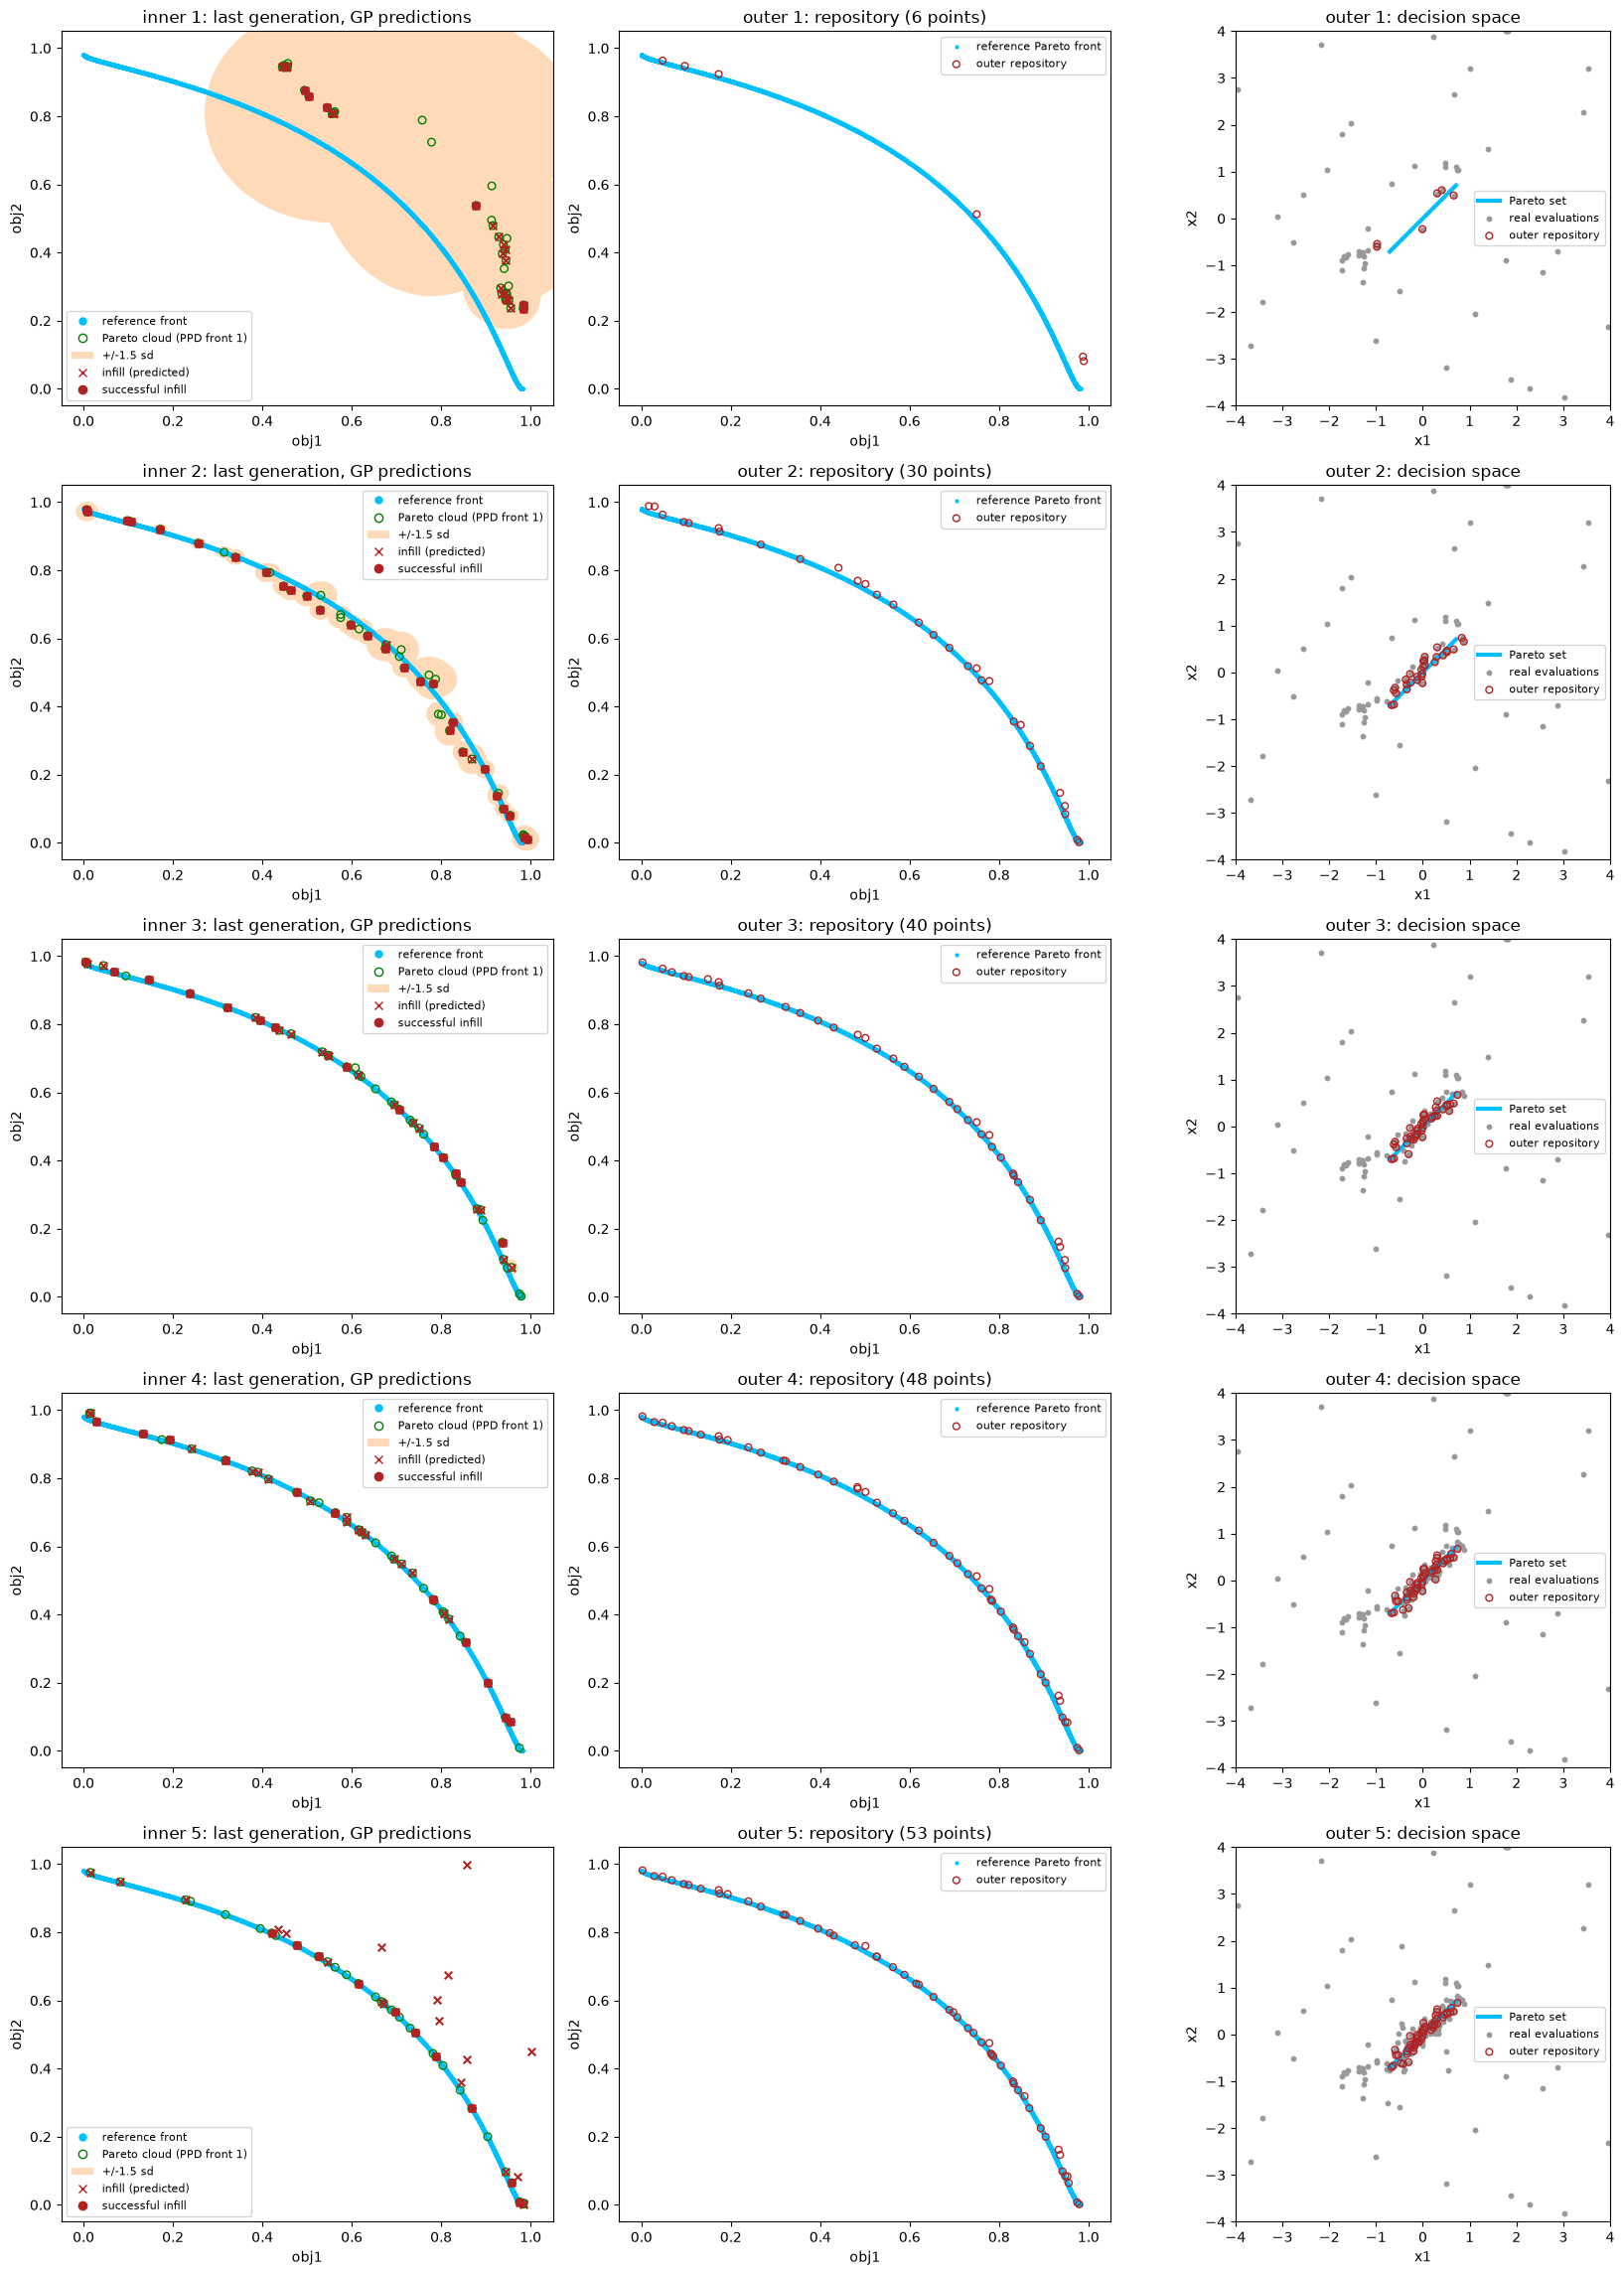

In [8]:
fig, axes = plt.subplots(len(rounds), 3, figsize=(17, 4.6 * len(rounds)), squeeze=False)
for k, r in enumerate(rounds):
    ax = axes[k, 0]
    ax.scatter(TRUE_F[:, 0], TRUE_F[:, 1], s=4, c="deepskyblue")
    for _, row in r["cloud"].iterrows():
        ax.add_patch(Ellipse((row["obj1"], row["obj2"]), width=3 * row["obj1_sd"],
                             height=3 * row["obj2_sd"], fc="peachpuff", ec="none", zorder=-10))
    ax.scatter(r["cloud"]["obj1"], r["cloud"]["obj2"], s=30, facecolors="none", edgecolors="g")
    pred = r["infill_pred"].dropna()
    ax.scatter(pred["obj1"], pred["obj2"], s=30, marker="x", c="firebrick", zorder=5)
    hit = r["infill_pred"].loc[r["success"]].dropna()
    ax.scatter(hit["obj1"], hit["obj2"], s=30, c="firebrick", zorder=6)
    ax.set_xlim(*F_XLIM), ax.set_ylim(*F_YLIM)
    ax.set_xlabel("obj1"), ax.set_ylabel("obj2")
    ax.set_title("inner {0}: last generation, GP predictions".format(k + 1))
    ax.legend(handles=[
        Line2D([], [], ls="", marker="o", mfc="deepskyblue", mec="none", label="reference front"),
        Line2D([], [], ls="", marker="o", mfc="none", mec="g", label="Pareto cloud (PPD front 1)"),
        Patch(facecolor="peachpuff", label="+/-1.5 sd"),
        Line2D([], [], ls="", marker="x", c="firebrick", label="infill (predicted)"),
        Line2D([], [], ls="", marker="o", c="firebrick", label="successful infill")], fontsize=8)
    plot_outer(k + 1, axes[k, 1])
    plot_dv(k + 1, axes[k, 2])
plt.tight_layout()
plt.show()

## Comparison: MOU on the real model with the same budget

To see what the surrogate buys, this cell runs plain `pestpp-mou` on the real function with the
same budget: the same population size (`OUTER_POP`), starting from the same initial LHS and running
`N_OUTER` generations. Both runs then make the same number of real evaluations. The IGD of each
run's repository after every round/generation measures how close it is to the reference front.

noptmax:5, npar_adj:2, nnz_obs:4
processing control file fon.pst
Note: 3 unused lines in pest control file, see rec file...


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....:::::::::____  ... :
   :... `:~    ^~-:::::..  .........:::::-~^    ~::.::::
   `.::. `\   (8)  \b:::..::.:.:::::::d/  (8)   /'.::::'
    ::::.  ~-._v    |b.::::::::::::::d|    v_.-~..:::::
    `.:::::... ~~^?888b..:::::::::::d888P^~...::::::::'
     `.::::::::::....~~~ .:::::::::~~~:::::::::::::::'
      `..:::::::::::   .   ....::::    ::::::::::::,'
        `. .:::::::    .      .::::.    ::::::::'.'
          `._ .:::   

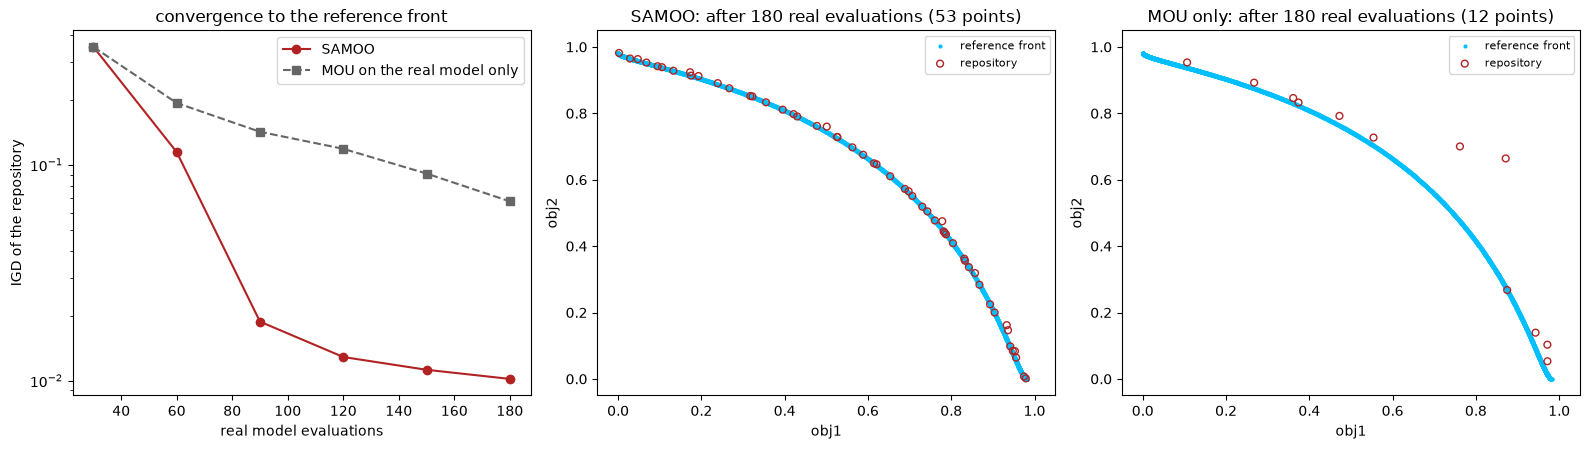

In [9]:
moo_pst = build_pst(MOO_DIR, REAL_FORWARD_RUN, "real_forward_run.py",
                    population_size=OUTER_POP, noptmax=N_OUTER)
moo = Mou.from_pst(moo_pst, workdir=MOO_DIR, workers=N_WORKER_OUTER, port=4043)
moo.set_option("random_seed", 42)
moo.initialize(defer_runs=True)
moo.set_par_df(initial_dv.set_axis(moo.dv_pop().index))
moo.queue_runs()
moo.run()
moo.process_runs()
moo.finish_initialize()
moo_repo = [moo.archive_obs(lower=True)[OBJ_NAMES]]
for step in moo.iterations():
    moo_repo.append(moo.archive_obs(lower=True)[OBJ_NAMES])
moo.finalize()
moo.close()

budget = [OUTER_POP * (k + 1) for k in range(N_OUTER + 1)]
igd_samoo = [igd(obs.values) for _, obs in repo_history]
igd_moo = [igd(obs.values) for obs in moo_repo]
print(pd.DataFrame({"real evaluations": budget, "SAMOO IGD": igd_samoo, "MOU-only IGD": igd_moo},
                   index=pd.Index(range(N_OUTER + 1), name="round")).round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
ax.plot(budget, igd_samoo, "o-", c="firebrick", label="SAMOO")
ax.plot(budget, igd_moo, "s--", c="0.4", label="MOU on the real model only")
ax.set_xlabel("real model evaluations"), ax.set_ylabel("IGD of the repository")
ax.set_yscale("log"), ax.set_title("convergence to the reference front"), ax.legend()

for ax, obs, name in ((axes[1], repo_history[-1][1], "SAMOO"), (axes[2], moo_repo[-1], "MOU only")):
    ax.scatter(TRUE_F[:, 0], TRUE_F[:, 1], s=4, c="deepskyblue", label="reference front")
    ax.scatter(obs["obj1"], obs["obj2"], s=24, facecolors="none", edgecolors="firebrick",
               zorder=10, label="repository")
    ax.set_xlim(*F_XLIM), ax.set_ylim(*F_YLIM)
    ax.set_xlabel("obj1"), ax.set_ylabel("obj2"), ax.legend(fontsize=8)
    ax.set_title("{0}: after {1} real evaluations ({2} points)".format(name, budget[-1], len(obs)))
plt.tight_layout()
plt.show()

outer.finalize()
outer.close()

## Notes


- **Surrogate.** Each candidate subprocess fits a local GP per objective (`start=6`, `end=20`, ALC, isotropic squared-exponential kernel). For larger training sets, fitting one full `GaussianProcess` per round (as `bbgo_rosenbrock2d_via_api.ipynb` does) avoids refitting in every candidate.
- **Inner starting population.** The inner population has a fixed row count (`INNER_POP`, 30).
  When the outer repository has fewer than 30 points, a round starts from the whole repository
  plus a random sample of the latest outer round's other evaluations, then of older ones.
- **Inner starting objectives.** The starting points are real evaluations, so they start with
  their real objectives instead of running through the surrogate. They're loaded with
  `mou_dv_population_file` and `mou_obs_population_restart_file`, set on each round's session
  before `initialize()` (not in the template's `.pst`, which every round shares). There's no
  `set_obs_df()`, and after `initialize(defer_runs=True)` the queued runs would overwrite any
  obs written through `obs_view()` anyway. With a restart file, `initialize(defer_runs=True)`
  returns 0 and `finish_initialize()` follows directly. The real model reports `obj*_sd = 0`,
  and under PPD an sd below the synthetic minimum (`min_sd`, set from the spread of each front)
  is raised to that minimum, so a real point doesn't look perfectly certain.
- **Infill count = outer population size.** Candidate buffers can't be resized through the API, so `MAX_INFILL == OUTER_POP`. `pad_to()` fills with LHS points if the inner run offers too few new points; the loop prints a message when it does.
- **Outer repository.** One outer session lasts the whole run, so its archive already covers every round; no separate pass is needed to merge and re-sort the real evaluations.
- **The one file read back.** `resample()` reads the inner run's `fon.pareto.summary.csv`, because the API doesn't expose the per-generation PPD front ranks and crowding distances. The decision variables come from populations read through the API during the inner loop.
- **Reference front.** Analytic (the `x1 = x2` segment), sampled at 2001 points; it is used only for plots and IGD.